In [11]:
import pandas as pd
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [12]:
db_path = r"D:\Projects\Customer_Retention\mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{db_path.replace('\\', '/')}")

df_rfm = pd.read_parquet(r'D:\\Projects\\Customer_Retention\data\\02_rfm_features.parquet')

df_raw = pd.read_parquet(r'D:\\Projects\\Customer_Retention\data\\01_cleaned_retail.parquet')


In [13]:

model_name = "Best_Churn_Predictor"
model_uri = f"models:/{model_name}/latest"
best_model = mlflow.sklearn.load_model(model_uri)

features = ['Frequency', 'Monetary', 'F_Score', 'M_Score']


df_rfm['Churn_Probability'] = best_model.predict_proba(df_rfm[features])[:, 1]


In [14]:
clv_summary = summary_data_from_transaction_data(
    df_raw, 'Customer ID', 'InvoiceDate', 'Revenue',
    observation_period_end=df_raw['InvoiceDate'].max()
)
clv_summary = clv_summary[clv_summary['frequency'] > 0]

bgf = BetaGeoFitter(penalizer_coef=0.01).fit(clv_summary['frequency'], clv_summary['recency'], clv_summary['T'])
ggf = GammaGammaFitter(penalizer_coef=0.01).fit(clv_summary['frequency'], clv_summary['monetary_value'])

clv_summary['6_Month_CLV'] = ggf.customer_lifetime_value(
    bgf, clv_summary['frequency'], clv_summary['recency'], clv_summary['T'], clv_summary['monetary_value'],
    time=6, discount_rate=0.01
)

master_df = df_rfm.merge(clv_summary[['6_Month_CLV']], left_on='Customer ID', right_index=True, how='left')
master_df['6_Month_CLV'] = master_df['6_Month_CLV'].fillna(0) # For non-repeaters

print("Master Action Table Created!")
master_df[['Customer ID', 'Segment_Label', 'Churn_Probability', '6_Month_CLV']].head()

Master Action Table Created!


,Customer ID,Segment_Label,Churn_Probability,6_Month_CLV
0,12346,Loyal Customers,0.212608,11549.926563
1,12347,Champions,0.278597,1805.060997
2,12348,Loyal Customers,0.416994,782.090108
3,12349,Champions,0.423398,1273.462509
4,12350,At Risk,0.791136,0.000000


In [15]:
HIGH_CHURN_THRESHOLD = 0.70  # Top 30% risk
HIGH_VALUE_THRESHOLD = master_df['6_Month_CLV'].quantile(0.80) 

def segment_strategy(row):
    if row['6_Month_CLV'] >= HIGH_VALUE_THRESHOLD:
        if row['Churn_Probability'] >= HIGH_CHURN_THRESHOLD:
            return "VIP - Save Immediately" 
        else:
            return "VIP - Loyalty Program" 
    else:
        if row['Churn_Probability'] >= HIGH_CHURN_THRESHOLD:
            return "Low Value - Do Not Target" 
        else:
            return "Standard - Maintenance" 

master_df['Action_Strategy'] = master_df.apply(segment_strategy, axis=1)

print("Strategy Distribution:")
print(master_df['Action_Strategy'].value_counts())

Strategy Distribution:
Action_Strategy
Standard - Maintenance       2922
Low Value - Do Not Target    1780
VIP - Loyalty Program        1176
Name: count, dtype: int64


In [16]:
print("--- Data Distribution Check ---")
print(f"Max Churn Probability: {master_df['Churn_Probability'].max():.2f}")
print(f"90th Percentile of Churn Prob: {master_df['Churn_Probability'].quantile(0.90):.2f}")
print(f"Number of VIPs (Top 20% Value): {len(master_df[master_df['6_Month_CLV'] >= HIGH_VALUE_THRESHOLD])}")

max_vip_risk = master_df[master_df['6_Month_CLV'] >= HIGH_VALUE_THRESHOLD]['Churn_Probability'].max()
print(f"Highest Churn Risk among VIPs: {max_vip_risk:.2f}")

--- Data Distribution Check ---
Max Churn Probability: 0.86
90th Percentile of Churn Prob: 0.80
Number of VIPs (Top 20% Value): 1176
Highest Churn Risk among VIPs: 0.69


In [17]:
VAL_75 = master_df['6_Month_CLV'].quantile(0.75)
vip_mask = master_df['6_Month_CLV'] >= VAL_75

vip_risk_threshold = master_df.loc[vip_mask, 'Churn_Probability'].quantile(0.50) if vip_mask.sum() > 0 else 0

master_df['Action_Strategy'] = master_df.apply(
    lambda x: "VIP - Save Immediately" if (x['6_Month_CLV'] >= VAL_75 and x['Churn_Probability'] >= vip_risk_threshold)
    else ("VIP - Loyalty" if x['6_Month_CLV'] >= VAL_75 else "Standard"), axis=1
)

print(f"VIP Risk Threshold (50th percentile within VIPs): {vip_risk_threshold:.4f}")
print(f"Total VIPs identified: {vip_mask.sum()}")
print(f"VIPs at-risk (for Save Immediately): {(master_df['Action_Strategy'] == 'VIP - Save Immediately').sum()}")

vip_save = master_df[master_df['Action_Strategy'] == "VIP - Save Immediately"]
avg_clv = vip_save['6_Month_CLV'].mean() if not vip_save.empty else 0

total_cost = len(vip_save) * 20.0 
revenue_saved = (len(vip_save) * 0.15) * avg_clv 
net_profit = revenue_saved - total_cost

print(f"\n--- FINAL STRATEGY RESULTS ---")
print(f"Total VIPs to Save: {len(vip_save)}")
print(f"Average Value of these VIPs: ${avg_clv:,.2f}")
print(f"Potential Revenue to Recover: ${revenue_saved:,.2f}")
print(f"Net Campaign Profit (after costs): ${net_profit:,.2f}")

VIP Risk Threshold (50th percentile within VIPs): 0.1747
Total VIPs identified: 1470
VIPs at-risk (for Save Immediately): 739

--- FINAL STRATEGY RESULTS ---
Total VIPs to Save: 739
Average Value of these VIPs: $1,669.42
Potential Revenue to Recover: $185,055.00
Net Campaign Profit (after costs): $170,275.00


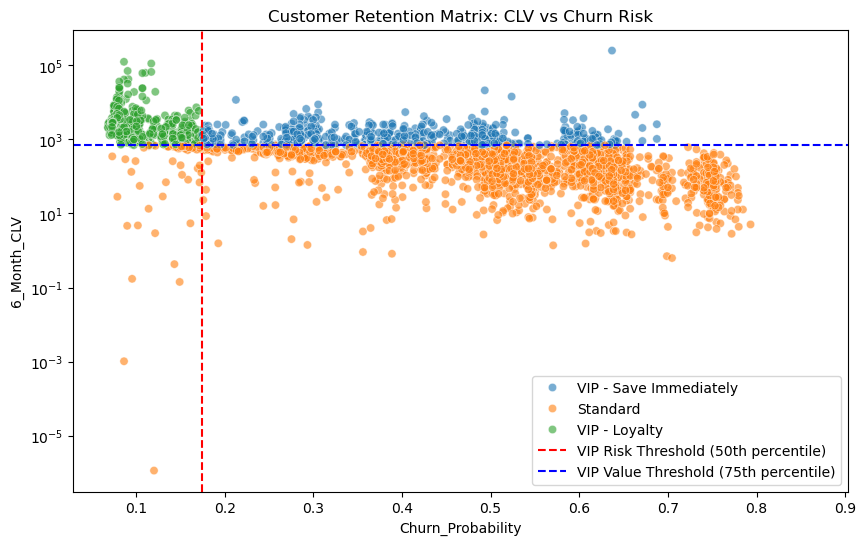

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='Churn_Probability', y='6_Month_CLV', 
                hue='Action_Strategy', alpha=0.6)
plt.axvline(vip_risk_threshold, color='red', linestyle='--', label='VIP Risk Threshold (50th percentile)')
plt.axhline(VAL_75, color='blue', linestyle='--', label='VIP Value Threshold (75th percentile)')
plt.title('Customer Retention Matrix: CLV vs Churn Risk')
plt.yscale('log') 
plt.legend()
plt.show()

In [19]:
COUPON_VALUE = 20.0  
SUCCESS_RATE = 0.15   


vip_save = master_df[master_df['Action_Strategy'] == "VIP - Save Immediately"]
avg_clv = vip_save['6_Month_CLV'].mean() if not vip_save.empty else 0

total_cost = len(vip_save) * COUPON_VALUE
revenue_saved = (len(vip_save) * SUCCESS_RATE) * avg_clv
net_profit = revenue_saved - total_cost

print(f"--- Updated ROI Simulation ---")
print(f"Targeting {len(vip_save)} at-risk VIPs")
print(f"Estimated Revenue Saved: ${revenue_saved:,.2f}")
print(f"Net Campaign Profit: ${net_profit:,.2f}")

--- Updated ROI Simulation ---
Targeting 739 at-risk VIPs
Estimated Revenue Saved: $185,055.00
Net Campaign Profit: $170,275.00


In [ ]:
master_df.to_parquet(r'D:\\Projects\\Customer_Retention\\data\\03_final_customer_insights.parquet')
print("Final insights saved!")

Phase 4 Complete: Final insights saved to data folder!
